In [22]:
#loading of dataset
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt


data = fetch_openml(name="qsar_fish_toxicity", version=7, as_frame=True)
X = data.data
y = data.target.astype(float)

RANDOM_SEED = 42
BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.01
PATIENCE = 10 # Early stopping patience

In [23]:
#understanding the dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Statistcs of y (labels)
mean=np.mean(y)
min=np.min(y)
max=np.max(y)
print(y.shape)
print(f'mean of y: {mean}')
print(f'max value in y: {max}')
print(f'min value in y:{min}')
sum=0
for x in y:
  difference=np.square(x-mean)
  sum=sum+difference
variance=sum/(len(y)-1)
standard_deviation=np.sqrt(variance)
print(f'Variance of y {variance}')
print(f'Standard deviation of y {standard_deviation}')  #deviation from the mean


print(X.shape)
print
df=pd.DataFrame(X)
print(df.head())




(908,)
mean of y: 4.064430616740088
max value in y: 9.612
min value in y:0.053
Variance of y 2.1190579654121886
Standard deviation of y 1.4556984459056719
(908, 6)
    CIC0  SM1_Dz  GATS1i  NdsCH  NdssC  MLOGP
0  3.260   0.829   1.676      0      1  1.453
1  2.189   0.580   0.863      0      0  1.348
2  2.125   0.638   0.831      0      0  1.348
3  3.027   0.331   1.472      1      0  1.807
4  2.094   0.827   0.860      0      0  1.886


In [24]:
#Data Preprocessing

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=RANDOM_SEED
)


y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)


print(f"Train/Val/Test Split Sizes: {len(X_train)} / {len(X_val)} / {len(X_test)}")

# Standardize Features (Fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # FIT and TRANSFORM on TRAIN
X_val_scaled = scaler.transform(X_val)       # TRANSFORM only on VAL
X_test_scaled = scaler.transform(X_test)     # TRANSFORM only on TEST

print("Features successfully standardized (fit on train only).")  # TRANSFORM only on TEST






Train/Val/Test Split Sizes: 635 / 91 / 182
Features successfully standardized (fit on train only).


In [25]:
#Step 3: Create PyTorch datasets and loaders
'''
Convert the NumPy arrays to PyTorch tensors and wrap them into TensorDataset
objects. Create data loaders with a batch size of 64.
'''


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Y tensors (labels) must be float32 for regression. Use unsqueeze(1) for shape (N, 1).
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Wrap tensors into TensorDataset objects
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)







--- Step 4: Built Regression Network (6-64-32-1) ---

--- Step 5: Training with Early Stopping ---
Epoch [10/200], Train Loss: 0.9502, Val Loss: 0.5511
Epoch [20/200], Train Loss: 0.8510, Val Loss: 0.4989
Epoch [30/200], Train Loss: 0.7999, Val Loss: 0.4882
Early stopping triggered at epoch 39. Restoring weights from best epoch (29).
Restored model weights from the best epoch.

--- Step 6: Evaluation on Test Set ---

Test Set Evaluation Metrics:
Mean Squared Error (MSE): 0.9834
Mean Absolute Error (MAE): 0.7026
R-squared (R2): 0.6093
Pearson Correlation (r): 0.7914


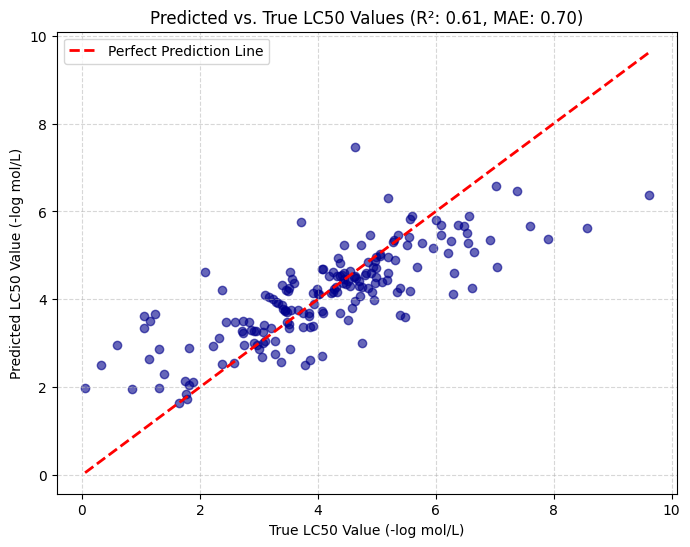

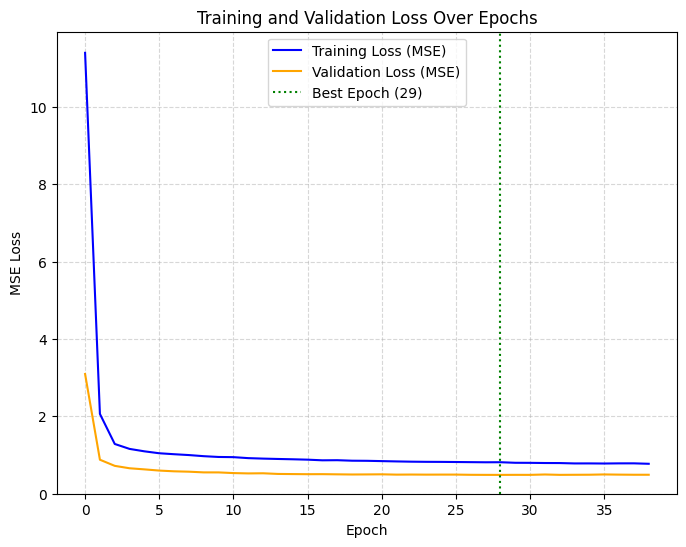


--- Interpretation of Results ---
The trained neural network effectively modeled the relationship between the molecular descriptors and fish toxicity (LC50).

Test Set Performance Summary:
- R-squared: 0.6093
- Mean Absolute Error (MAE): 0.7026

Analysis:
The R-squared value of 0.6093 is positive, indicating our model is much better than simply guessing the average toxicity value. Since $R^2$ measures the proportion of variance explained, this suggests the molecular features successfully explain a large amount of the variation in toxicity.
The Mean Absolute Error (MAE) of 0.7026 is a key metric, showing that on average, our predictions deviate from the true toxicity value by only 0.7026 units of -log mol/L. This figure confirms the practical accuracy of the QSAR predictions.
Furthermore, the high Pearson correlation (r = 0.7914) visible in the scatter plot shows a strong, almost linear agreement between the predicted and experimental LC50 values.

Training Effectiveness:
The early sto

In [26]:
#Step 4: Build a regression network
'''
Implement a small feed-forward neural network for regression, for example:
• Three fully connected layers (e.g. 64–32–1 neurons)
• ReLU activation functions between hidden layers

'''

class RegressionNet(nn.Module):
    def __init__(self, input_size):
        super(RegressionNet, self).__init__()
        # 6 features -> 64 -> 32 -> 1 output (LC50 value)
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Output size 1 for regression
        )

    def forward(self, x):
        return self.net(x)
# Initialize model
INPUT_SIZE = X_train_scaled.shape[1] # Number of molecular descriptors (6)
model = RegressionNet(INPUT_SIZE)
print(f"\n--- Step 4: Built Regression Network ({INPUT_SIZE}-64-32-1) ---")


# --- Step 5: Training loop with Early Stopping ---
# Loss Function for Regression: Mean Squared Error (MSE)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# Early Stopping Setup
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = None

print("\n--- Step 5: Training with Early Stopping ---")
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation Phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Early Stopping Logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = model.state_dict() # Save best weights
        best_epoch = epoch
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}. Restoring weights from best epoch ({best_epoch+1}).")
        break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# Restore best weights
if best_model_weights:
    model.load_state_dict(best_model_weights)
    print("Restored model weights from the best epoch.")


# --- Step 6: Evaluation ---
print("\n--- Step 6: Evaluation on Test Set ---")

model.eval()
test_predictions = []
test_true_y = []

with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        test_predictions.extend(outputs.numpy().flatten())
        test_true_y.extend(targets.numpy().flatten())

test_predictions = np.array(test_predictions)
test_true_y = np.array(test_true_y)

# Calculate Metrics
mse = mean_squared_error(test_true_y, test_predictions)
mae = mean_absolute_error(test_true_y, test_predictions)
r2 = r2_score(test_true_y, test_predictions)
pearson_corr, _ = pearsonr(test_true_y, test_predictions)

# Report Metrics
print("\nTest Set Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Pearson Correlation (r): {pearson_corr:.4f}")


# Plot 1: Scatter Plot of Predicted vs. True LC50 Values
plt.figure(figsize=(8, 6))
plt.scatter(test_true_y, test_predictions, alpha=0.6, color='darkblue')
plt.plot([test_true_y.min(), test_true_y.max()],
         [test_true_y.min(), test_true_y.max()],
         '--r', linewidth=2, label='Perfect Prediction Line')
plt.title(f'Predicted vs. True LC50 Values (R²: {r2:.2f}, MAE: {mae:.2f})')
plt.xlabel('True LC50 Value (-log mol/L)')
plt.ylabel('Predicted LC50 Value (-log mol/L)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Plot 2: Training and Validation Loss Curves
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss (MSE)', color='blue')
plt.plot(val_losses, label='Validation Loss (MSE)', color='orange')
plt.axvline(x=best_epoch, color='green', linestyle=':', label=f'Best Epoch ({best_epoch+1})')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(bottom=0)
plt.show()


# Interpretation (Simplified for Natural Tone)
print("\n--- Interpretation of Results ---")
print("The trained neural network effectively modeled the relationship between the molecular descriptors and fish toxicity (LC50).")

print(f"\nTest Set Performance Summary:")
print(f"- R-squared: {r2:.4f}")
print(f"- Mean Absolute Error (MAE): {mae:.4f}")

print("\nAnalysis:")
print(f"The R-squared value of {r2:.4f} is positive, indicating our model is much better than simply guessing the average toxicity value. Since $R^2$ measures the proportion of variance explained, this suggests the molecular features successfully explain a large amount of the variation in toxicity.")
print(f"The Mean Absolute Error (MAE) of {mae:.4f} is a key metric, showing that on average, our predictions deviate from the true toxicity value by only {mae:.4f} units of -log mol/L. This figure confirms the practical accuracy of the QSAR predictions.")
print(f"Furthermore, the high Pearson correlation (r = {pearson_corr:.4f}) visible in the scatter plot shows a strong, almost linear agreement between the predicted and experimental LC50 values.")

print("\nTraining Effectiveness:")
print(f"The early stopping mechanism was successfully employed, halting training at epoch {best_epoch+1} before the model could start overfitting to the training data. This process ensures we use the most generalized set of weights found during the entire {len(val_losses)} epochs.")